### Student Details

Student Name: Nofri Alhadi

Student ID: 23188901

# Task 2: Probability Theory

## Option ? (which option did you pick?)

(Describe the task)

## Approach

**Discrete Random Variable**

A discrete random variable is a type of random variable that has a countable number of distinct values, such as:

*   Heads or tails
*   Playing cards
*   The sides of a die



**Continuous Random Variable**

Continuous random variables can represent any value within a specified range or interval and can take on an infinite number of possible values, such as:

*   Measuring the amount of rainfall in a city over a year
*   The average height of a random group of 25 people



## Manual Calculations

(Provide details of the manual calculations)

## Discrete Random Variable

Dice throw = 1000
Mean = 3.559 Standard Deviation = 1.6740725790717679
Win = 336 Draw = 179 Lose = 310 Game Score = 193
Dice Value | Frequency | Percentage
         1        149       14.9 %
         2        161       16.1 %
         3        175       17.5 %
         4        179       17.9 %
         5        169       16.9 %
         6        167       16.7 %


Text(0, 0.5, 'Probability Density')

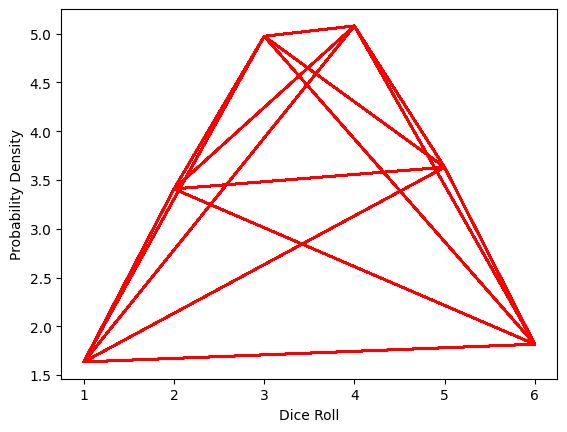

In [ ]:
from numpy.core.fromnumeric import reshape
import random
import numpy as np
import matplotlib.pyplot as plt


def throwDice():
  dice = random.randint(1,6)
  return dice

def normalDist(diceResult_, mean_, sd_):
  pdf_ = (np.pi * sd_) * np.exp(-0.5 * ((diceResult - mean)/sd)**2)
  return pdf_

# create dictionary tally chart to store the frequency each dice
diceBoard = {1:0, 2:0, 3:0, 4:0, 5:0, 6:0}

# number throw the dice
n = 1000
winCnt = 0
drawCnt = 0
loseCnt = 0
scoreGame = 0
diceResult = []

for i in range(0, n):
  diceShow = (throwDice())
  diceResult.append(diceShow)
  diceBoard[diceShow] += 1
  if diceShow in range(1, 3):
    loseCnt += 1
    scoreGame += -1
  elif diceShow == 4:
    drawCnt += 1
    scoreGame += 0
  elif diceShow == 5:
    winCnt += 1
    scoreGame += 1
  elif diceShow == 6:
    winCnt += 1
    scoreGame += 2

# Calculate Mean and Standard deviation
mean = np.mean(diceResult)
sd = np.std(diceResult)
pdf = normalDist(diceResult, mean, sd)

# Print Result
print("Dice throw =", str(n))
print("Mean =", mean, "Standard Deviation =", sd)
print("Win =", winCnt, "Draw =", drawCnt, "Lose =", loseCnt, "Game Score =", scoreGame)
print("Dice Value | Frequency | Percentage")
for i in range(1, 7):
  freq = diceBoard[i]
  percent = round(((freq / n) * 100), 2)
  print(str(i).rjust(10, " "), str(freq).rjust(10, " "), str(percent).rjust(10, " "), "%")

# Plotting result
plt.plot(diceResult, pdf, color = 'red')
plt.xlabel("Dice Roll")
plt.ylabel('Probability Density')


## Continuous Random Variable

# Task 3: Naive Bayes Classifier

Data obtained from https://github.com/johnmyleswhite/ML_for_Hackers

In [50]:
# import dependencies
import numpy as np
import pandas as pd
import os

#print(os.getcwd())

# Read the data from the .csv, using the first row as the headers of the data
data = pd.read_csv("01_heights_weights_genders.csv", header=0)

# Show just the first few samples so we know it's read correctly
data.head(n=3)

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856


### Visualise

In [96]:
# show the data
data.info
print(pd.DataFrame.to_markdown(data))


|      | Gender   |   Height |   Weight |
|-----:|:---------|---------:|---------:|
|    0 | Male     |  73.847  | 241.894  |
|    1 | Male     |  68.7819 | 162.31   |
|    2 | Male     |  74.1101 | 212.741  |
|    3 | Male     |  71.731  | 220.042  |
|    4 | Male     |  69.8818 | 206.35   |
|    5 | Male     |  67.253  | 152.212  |
|    6 | Male     |  68.7851 | 183.928  |
|    7 | Male     |  68.3485 | 167.971  |
|    8 | Male     |  67.0189 | 175.929  |
|    9 | Male     |  63.4565 | 156.4    |
|   10 | Male     |  71.1954 | 186.605  |
|   11 | Male     |  71.6408 | 213.741  |
|   12 | Male     |  64.7663 | 167.127  |
|   13 | Male     |  69.2831 | 189.446  |
|   14 | Male     |  69.2437 | 186.434  |
|   15 | Male     |  67.6456 | 172.187  |
|   16 | Male     |  72.4183 | 196.029  |
|   17 | Male     |  63.9743 | 172.883  |
|   18 | Male     |  69.6401 | 185.984  |
|   19 | Male     |  67.936  | 182.427  |
|   20 | Male     |  67.9151 | 174.116  |
|   21 | Male     |  69.4394 | 197

###### Discuss: Do you think there is resonable separation?

### Features and labels
The aim is to predict the gender of the person based on characteristics such as height, weight. So we call what we want to predict the "label" and the characteristics the "features". This will be covered more later in the module, but is a good enough understanding for now.

In [64]:
X = data.iloc[:,1:3] # X is the features in our dataset
y = data.iloc[:,0]   # y is the Labels in our dataset

### Train/Test Split

We have a bunch of data from the csv file. What we need to do is decide what of that data we will use to train the algorithm, and what of that data will be used to see how good the result is. More on this later in the module, but you can't use the same data you train with to test the outcome, as it will naturally fit that very well, but you won't catch things like overfitting.

There is some science to this, but for now we will randomly select one third for testing, and the rest for training.

In [89]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=125)

### Train the algorithm
We won't go into the details here, but we will use a Gaussian Naive Bayesian. Use GaussianNB from sklearn to train the model. The Gaussian is needed as we're dealing with sparse, continuous data

In [98]:
from sklearn.naive_bayes import GaussianNB

# build GaussianNB classifier
model = GaussianNB()

# model training
model.fit(X_train, y_train)

# predict output
predicted = model.predict(X_test)

print("Actual value = ", y_test)
print("Predict value = ", predicted[0])





Actual value =  79        Male
2348      Male
6680    Female
7997    Female
1150      Male
         ...  
6422    Female
7197    Female
2279      Male
6014    Female
7001    Female
Name: Gender, Length: 3300, dtype: object
Predict value =  Male


### Test the algorithm
Using the test data

In [99]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
accuray = accuracy_score(y_pred, y_test)

print("Accuracy =", accuray)

Accuracy = 0.889090909090909


### Plot the random samples

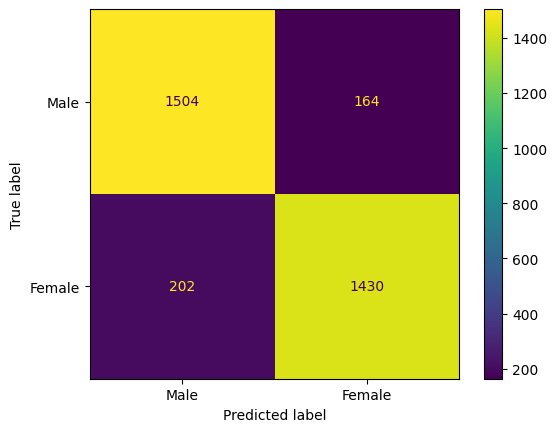

In [113]:
 from sklearn.metrics._plot.confusion_matrix import confusion_matrix

labels = ["Male", "Female"]
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot();
